<h3>Importing my development version of ShadowGrouping</h3>

In [1]:
import sys, numpy as np, time, pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import matplotlib.pyplot as plt
from IPython.display import Image, display
from os import mkdir
from os.path import isdir, isfile
from pathlib import Path
from random import randrange
import json

# adding ShadowGrouping package to the system path
# SG_package_path = r"G:\\My Drive\\Work\\Research\\Numerics\\ShadowGrouping Code\\"
#SG_package_path = r"C:\Users\aebad\shadowgrouping\\"
SG_package_path = r"C:\Users\Abbas\Priori\\"
sys.path.insert(0, SG_package_path)
#savename = ".txt" # insert {mapping_name}
savepath = Path("generated_data/convexoptimization/")
savepath.mkdir(parents=True, exist_ok=True)
# defining path where Hamiltonians are stored
folder_Hamiltonians = SG_package_path + "Hamiltonians_v2\\"

In [2]:
from shadowgrouping_v2.measurement_schemes import L1_sampler, Derandomization
#from shadowgrouping.measurement_schemes import Shadow_Grouping
from shadowgrouping.measurement_schemes_Shadowupdate import Priori, Posteriori, Shadow_Grouping, Best_scheme_given_pool, Shadow_Grouping_STD, AdaptiveShadows, Derandomization, Best_scheme_given_pool_new
from shadowgrouping_v2.weight_functions import Bernstein_bound
from shadowgrouping_v2.energy_estimator import Energy_estimator, StateSampler, Sign_estimator
from shadowgrouping_v2.helper_functions import (
    setting_to_str, char_to_int, int_to_char, settings_to_dict, prepare_settings_for_numba, gaussian_weights, gaussian_random_paulis, uniform_weights, uniform_random_paulis,
    sample_obs_from_setting, setting_to_str, setting_to_obs_form, sample_obs_batch_from_setting_batch, sample_obs_batch_from_setting_batch_numba, bootstrap_rmse)
from shadowgrouping_v2.shadowgrouping_my_dev.helper_functions import combine_seed
from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state
from shadowgrouping_v2.guarantees import (
    get_epsilon_Bernstein, get_epsilon_Bernstein_no_restricted_validity, 
    get_epsilon_Bernstein_tighter, get_epsilon_Bernstein_tighter_no_restricted_validity, 
    get_epsilon_Bernstein_scalar, get_epsilon_Bernstein_scalar_no_restricted_validity,
    get_epsilon_Bernstein_scalar_tighter, get_epsilon_Bernstein_scalar_tighter_no_restricted_validity, 
    get_epsilon_Hoeffding_scalar, get_epsilon_Hoeffding_scalar_tighter, get_epsilon_Chebyshev_scalar, 
    get_epsilon_Chebyshev_scalar_tighter, get_epsilon_single_Hoeffding_plus_union_bound,
    get_epsilon_Chebyshev_scalar_numba, get_epsilon_Chebyshev_scalar_tighter_numba,
    get_epsilon_Hoeffding_scalar_numba, get_epsilon_Hoeffding_scalar_tighter_numba,
    get_diagonal_proxy_of_variance)
from guarantees.exact_covariances import covariance_matrix
from guarantees.guarantees import get_epsilon_Chebyshev_scalar_tighter_numba, get_epsilon_Chebyshev_scalar_tightest_numba, _chebyshev_tightest_core
from shadowgrouping.poolgenerators import Priori_Pool , OGM_Pool, AEQUO_Pool, AEQUO_Pool_weightbased, OGM_NPBC, OGM_PBC, LDF_Sorted_Insertion_OGM, Shadow_Grouping_FC
from shadowgrouping_v2.AEQuO import AEQuO

C:\Users\Abbas\AppData\Local\Temp\ipykernel_12128\4028770266.py:10: NatureDeprecationWarning: The qiskit_nature.drivers.second_quantization package is deprecated as of version 0.5.0 and will be removed no sooner than 3 months after the release. Instead use the qiskit_nature.second_q.drivers package.
  from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state


<h3>Choosing molecule, basis set and fermion-to-qubit mapping</h3>

In [3]:
molecule_name = "LiH" # choose one out of the molecules ['H2', 'H2_6-31g', 'LiH', 'BeH2', 'H2O', 'NH3']
mapping_name = "JW" # choose one out of ["JW","BK","Parity"]
if molecule_name == 'H2':
    basis_set = "6-31g"
else:
    basis_set = "sto3g"
num_qubits = {'H2': 8, 'LiH': 12, 'BeH2': 14, 'H2O': 14, "NH3": 16} # number of qubits in which Hamiltonian is defined
savename = molecule_name + "_molecule_" + mapping_name + "_" + basis_set
folder_OGM_settings = "OGM_probabilities/OGM_{}_{}{}.txt" # format string to fill in {molecule}x{qubit_number}x{mapping}

<h3>Import the original hamiltonian file</h3>

In [4]:
# ensure the folder exists
import os


assert os.path.isdir(folder_Hamiltonians), f"Path '{folder_Hamiltonians}' does not exist or is not a directory."
    # find folder matching molecule + basis name
available_folders = os.listdir(folder_Hamiltonians)
prefix = f"{molecule_name}_{basis_set}"
folder_name = None
for folder in available_folders:
    if folder.startswith(prefix):
        folder_name = folder
        break

assert folder_name is not None, f"File not found for molecule '{molecule_name}' and basis set '{basis_set}'."
full_folder_path = os.path.join(folder_Hamiltonians, folder_name)

    # look for encoding and energy file
available_files = os.listdir(full_folder_path)
    
    #print(f"full path to folder",full_folder_path)
file_name = None
file_energy = None
for file in available_files:
    if file.lower().startswith(mapping_name[:2].lower()) and "grouped" not in file:
        file_name = file
    elif file == "ExactEnergy.txt":
        file_energy = file

assert file_name is not None, f"File not found for encoding '{mapping_name}'."
assert file_energy is not None, "File not found for ground-state energy."
    
print(f"full path to file",os.path.join(full_folder_path, file_name))

full path to file C:\Users\Abbas\Priori\\Hamiltonians_v2\LiH_sto3g_12qubits\jw.txt


<h3>Loading Prior Information</h3>

In [5]:
# Loading Hamiltonian
observables, w, offset, E_GS, state = load_pauli_list(folder_Hamiltonians,molecule_name,basis_set,mapping_name,diagonalize=False)

# loading exact ground state
path_to_GS = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs.txt"
with open(path_to_GS, 'r') as f:
    data_string = f.read()
state = data_string.split('\n')
state = state[:len(state)-1]
for i in range(len(state)):
    state[i] = complex(state[i])
state = np.array(state)

# Loading exact ground state energy
path_to_GS_energy = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs_energy.txt"
with open(path_to_GS_energy, 'r') as f:
    data_string = f.read()
E_GS = float(data_string)
print(f"Exact ground state energy: {E_GS}")

# Calculating exact covariances

sanity = False
tightest = True

if tightest:
    path_to_cov_real = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\cov_real_" + mapping_name + ".npy"
    os.makedirs(os.path.dirname(path_to_cov_real), exist_ok=True)
    if os.path.exists(path_to_cov_real):
        print("Loading exact covariance matrix from file...")
        #loading exact covariance matrix from file
        cov_real = np.load(path_to_cov_real)
    else:
        # Computing exact representation of full covariance matrix
        exact_covariances = covariance_matrix(state, observables)
        #print(np.round(exact_covariances,3))
        cov_real = np.ascontiguousarray(((exact_covariances + exact_covariances.conj().T).real) * 0.5, dtype=np.float64)
        # Save the computed covariance matrix to file for future runs
        np.save(path_to_cov_real, cov_real)
        print(f"Saved exact covariance matrix to {path_to_cov_real}")
if sanity:
        # Sanity check: Computing total variance using full matrix representation of Hamiltonian
        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)
        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)
        exp_value_H = np.dot(np.conjugate(state), H_dot_state)
        var_H = exp_value_H2 - exp_value_H**2
        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian

Exact ground state energy: -8.90829943147338
Loading exact covariance matrix from file...


<h3>Setting Parameters for Simulation</h3>

In [6]:
eps = 0.01
delta = 0.33
sampling_seed    = int(randrange(1000000))
alpha = np.max(np.abs(w))/np.min(np.abs(w)) + np.min(np.abs(w))
state_sampler = StateSampler(state)

<h3>Generating measurement scheme using Shadow_Grouping OR Priori<h3>

In [7]:
label = "OGM_FC" # Select the pool generation method: "SGP" for Shadow Grouping, "PP" for Priori_Pool, "OGMP" for Overlapped Grouping, "AEP" for AEQUO_Pool, "AEWP" for AEQUO_Weighted_Pool, "OGM_NPBC" for OGM without periodic boundary conditions, "STD" for steady_state_budget_allocation.
if label == "SGP":
    methodname = "SG Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 10000
    method_1 = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator_1.reset()
    points = 25
    prev = 0
    rmse_values = []
    rmse_stds = []
    epsilonbernstein_1_list = []
    epsilonchebyshevtighter_1_list = []
    epsilonchychev_tightest_1_list = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(1, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        epsilonbernstein_1 , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
        epsilonbernstein_1_list.append({"n": n, "epsilon": epsilonbernstein_1})
        print(f"Epsilon Bernstein for RE: {epsilonbernstein_1}")
        epsilonchebyshevtighter_1 = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
        epsilonchebyshevtighter_1_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1})
        print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1}")
        epsilonchychev_tightest_1 = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        epsilonchychev_tightest_1_list.append({"n": n, "epsilon": epsilonchychev_tightest_1})
        print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1}")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

if label == "PP":
    methodname = "Priori Pool"
    t_init_scheme_1 = time.time()
    method_1 = Priori_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)
    
if label == "OGMP":
    methodname = "OGM Pool-1"
    t_init_scheme_1 = time.time()
    # catch exception of missing data for OGM
    file = folder_OGM_settings.format(molecule_name,observables.shape[1],mapping_name.lower())
    if isfile(file):
        method_1 = OGM_Pool(observables,w,file)
        method_1.find_setting()
        t_end_scheme_1 = time.time()
        print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
        print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
        print(method_1.N_hits)
    else:
        print(f"File not found for OGM probabilities: {file}. Please run the OGM pool generation code to generate the required data.")


if label == "AEP":
    methodname = "LDF Pool + Non overlapping"
    t_init_scheme_1 = time.time()
    method_1 = AEQUO_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)


if label == "AEWP":
    methodname = "Sorted Insertion Pool"
    t_init_scheme_1 = time.time()
    method_1 = AEQUO_Pool_weightbased(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)


if label == "OGM_NPBC":
    methodname = "OGM Pool-2"
    t_init_scheme_1 = time.time()
    method_1 = OGM_NPBC(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)

if label == "OGM_PBC":
    methodname = "OGM Pool-PBC"
    t_init_scheme_1 = time.time()
    method_1 = OGM_PBC(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)


if label == "FC":
    methodname = "Full Commutativity Pools"
    t_init_scheme_1 = time.time()
    method_1 = LDF_Sorted_Insertion_OGM(observables, w, epsilon=0.1, total_rounds=0,
                 is_overlapping=False, commutativity_type="fc",
                 ordering_strategy="coefficient",
                 overlap_strategy="cyclic",
                 informed_allocation=True, allocation_objective="bernstein_l1",
                 attempt_truncation=False, rounding_strategy="largest_fraction",
                 md_gap_tol_rel=1e-4, prior_counts=None,
                 allocate_budget_in_init=True)
    method_1.find_groups()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)

if label == "STD":
    methodname = "SG-STD Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 13000000
    method_1 = Shadow_Grouping_STD(observables,w,eps,Bernstein_bound(alpha=alpha)(), save_scheme=False,handle_ties=True,compute_N_hits_pairs=True)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='qwc', qubit_connectivity=None)
    estimator_1.reset()
    points = 1
    prev = 0
    rmse_values = []
    rmse_stds = []
    epsilonbernstein_1_list = []
    epsilonchebyshevtighter_1_list = []
    epsilonchychev_tightest_1_list = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.steady_state_budget_allocation(num_steps= (n - prev), beta=0.01, verbose=True)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        epsilonbernstein_1 , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
        epsilonbernstein_1_list.append({"n": n, "epsilon": epsilonbernstein_1})
        print(f"Epsilon Bernstein for RE: {epsilonbernstein_1}")
        epsilonchebyshevtighter_1 = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
        epsilonchebyshevtighter_1_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1})
        print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1}")
        epsilonchychev_tightest_1 = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        epsilonchychev_tightest_1_list.append({"n": n, "epsilon": epsilonchychev_tightest_1})
        print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1}")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates_1 = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates_1, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": n, "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)


if label == "SGP_FC":
    methodname = "SG_FC Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 13000000
    method_1 = Shadow_Grouping_FC(observables,w,eps,Bernstein_bound(alpha=alpha)(),save_scheme=False,handle_ties=True,compute_N_hits_pairs=True,commutativity_type="fc")
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='fc', qubit_connectivity=None)
    estimator_1.reset()
    points = 1
    prev = 0
    rmse_values = []
    rmse_stds = []
    epsilonbernstein_1_list = []
    epsilonchebyshevtighter_1_list = []
    epsilonchychev_tightest_1_list = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        epsilonbernstein_1 , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
        epsilonbernstein_1_list.append({"n": n, "epsilon": epsilonbernstein_1})
        print(f"Epsilon Bernstein for RE: {epsilonbernstein_1}")
        epsilonchebyshevtighter_1 = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
        epsilonchebyshevtighter_1_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1})
        print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1}")
        epsilonchychev_tightest_1 = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        epsilonchychev_tightest_1_list.append({"n": n, "epsilon": epsilonchychev_tightest_1})
        print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1}")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

if label == "STD_FC":
    methodname = "STD_FC Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 1500000
    method_1 = Shadow_Grouping_FC(observables,w,eps,Bernstein_bound(alpha=alpha)(),save_scheme=False,handle_ties=True,compute_N_hits_pairs=True,commutativity_type="fc")
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='fc', qubit_connectivity=None)
    estimator_1.reset()
    points = 25
    prev = 0
    rmse_values = []
    rmse_stds = []
    epsilonbernstein_1_list = []
    epsilonchebyshevtighter_1_list = []
    epsilonchychev_tightest_1_list = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.steady_state_budget_allocation(num_steps= (n - prev), beta=0.01, verbose=True)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        epsilonbernstein_1 , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
        epsilonbernstein_1_list.append({"n": n, "epsilon": epsilonbernstein_1})
        print(f"Epsilon Bernstein for RE: {epsilonbernstein_1}")
        epsilonchebyshevtighter_1 = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
        epsilonchebyshevtighter_1_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1})
        print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1}")
        epsilonchychev_tightest_1 = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        epsilonchychev_tightest_1_list.append({"n": n, "epsilon": epsilonchychev_tightest_1})
        print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1}")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

if label == "OGM_FC":
    methodname = "Sorted Insertion Pool"
    #name = "OGM_1"
    Nreps_SGP = 100
    Nrounds_SGP = 500000
    #estimator_1.reset()
    points = 25
    prev = 0
    epsilonbernstein_1_list = []
    epsilonchebyshevtighter_1_list = []
    epsilonchychev_tightest_1_list = []
    diagonalvariance_1_list = []
    full_variance_1_list = []
    rmse_values = []
    rmse_stds = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(5, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        method_1 = LDF_Sorted_Insertion_OGM(observables, w, epsilon=0.01, total_rounds=int(n),
                         is_overlapping=False, commutativity_type="qwc",
                         ordering_strategy="coefficient",
                         overlap_strategy="top_first",
                         informed_allocation=True, allocation_objective="variance",
                         attempt_truncation=False, rounding_strategy="largest_fraction",
                         md_gap_tol_rel=1e-6, prior_counts=None,
                         allocate_budget_in_init=True)
        estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='qwc', qubit_connectivity=None)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        epsilonbernstein_1 , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
        epsilonbernstein_1_list.append({"n": n, "epsilon": epsilonbernstein_1})
        print(f"Epsilon Bernstein for RE: {epsilonbernstein_1}")
        diagonal_proxy_variance = get_diagonal_proxy_of_variance(estimator_1.measurement_scheme.N_hits, w)
        diagonalvariance_1_list.append({"n": n, "epsilon": diagonal_proxy_variance})
        print(f"Diagonal proxy variance for RE: {diagonal_proxy_variance}")
        full_variance , _ = _chebyshev_tightest_core(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        full_variance_1_list.append({"n": n, "epsilon": full_variance})
        print(f"Full Variance for RE: {full_variance}")
        epsilonchebyshevtighter_1 = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
        epsilonchebyshevtighter_1_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1})
        print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1}")
        epsilonchychev_tightest_1 = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
        epsilonchychev_tightest_1_list.append({"n": n, "epsilon": epsilonchychev_tightest_1})
        print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1}")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)


if label == "AEQUO_FC":
    methodname = "AEQUO Pool"
    Nreps_SGP = 1
    Nrounds_SGP = 10000
    method_1 = AEQuO(observables, w, offset, budget=0, commutativity_type="qwc")
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='qwc', qubit_connectivity=None)
    estimator_1.reset()
    points = 1
    prev = 0
    rmse_values = []
    rmse_stds = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(2, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        print(f"For {n} rounds:")
        print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 100000 rounds:
Number of different measurement settings:  144
Epsilon Bernstein for RE: 0.7323205528436473
Diagonal proxy variance for RE: 8.906188538514636e-05
Full Variance for RE: 0.008575510226150135
Epsilon Chebyshev (tighter) for RE: 0.07330347008389547
Epsilon Chebyshev (tightest) for RE: 0.008575510226150135


[Qibo 0.1.11|INFO|2026-08-26 16:50:56]: Using numpy backend on /CPU:0


Shots: 100000 | RMSE: 0.005306 | Std: 0.000382
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 106936 rounds:
Number of different measurement settings:  144
Epsilon Bernstein for RE: 0.7076766394731173
Diagonal proxy variance for RE: 8.328514534251381e-05
Full Variance for RE: 0.00829254908801659
Epsilon Chebyshev (tighter) for RE: 0.07088670622765623
Epsilon Chebyshev (tightest) for RE: 0.00829254908801659
Shots: 106936 | RMSE: 0.005719 | Std: 0.000348
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 114353 rounds:
Number of different measurement settings:  144
Epsilon Bernstein for RE: 0.6838941090660746
Diagonal proxy variance for RE: 7.788322902339483e-05
Full Variance for RE: 0.008019398036780968
Epsilon Chebyshev (tighter) for RE: 0.0685492751884535
Epsilon Chebyshev (tightest) for RE: 0.008019398036780968
Shots: 114353 | RMSE: 0.005345 | Std: 0.000375
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 122284 rou

MemoryError: Unable to allocate 2.70 GiB for an array with shape (30169800, 12) and data type int64

<h3>Trying Best_scheme_given_pool using the given pool in last cell<h3>

In [8]:
t_init_scheme_1re = time.time()
Nrounds = 500000
Nreps = 100
num_points = 25
epsilonbernstein_1re_list = []
epsilonchebyshevtighter_1re_list = []
epsilonchychev_tightest_1re_list = []
diagonalvariance_1re_list = []
full_variance_1re_list = []
rmse_re_list = []
rmse_se_re_list = []
sampling_points = np.unique(np.round(np.logspace(5, np.log10(Nrounds), max(num_points, 2))).astype(int))
if num_points == 1:
    sampling_points = np.array([Nrounds])
for n in sampling_points:
    method_1re = Best_scheme_given_pool_new(observables,w,method_1,eps,
                                        total_rounds=n,is_overlapping=False,
                                        commutativity_type="qwc", # 'qwc', 'fc' or 'kc' 
                                        informed_allocation=True,
                                        allocation_objective="variance", # 'variance' or 'bernstein_l1'
                                        attempt_truncation=False,
                                        rounding_strategy="marginal", # 'largest_fraction' or 'marginal'
                                        md_execution_mode = "until-converged",
                                        enable_pre_pruning = False,
                                        md_gap_tol_rel=1e-6,
                                        verbose=False)
    estimator_1re = Energy_estimator(method_1re,state_sampler,offset=offset,N_reps_exp=Nreps,
                                    compat_type='qwc', qubit_connectivity=None)
    print(f"For {n} rounds:")
    print("Number of different measurement settings: ", len(list(estimator_1re.measurement_scheme.settings_dict.keys())))
    epsilonbernstein_1re , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1re.measurement_scheme.N_hits, w, estimator_1re.measurement_scheme.settings_dict)
    epsilonbernstein_1re_list.append({"n": n, "epsilon": epsilonbernstein_1re})
    print(f"Epsilon Bernstein for RE: {epsilonbernstein_1re}")
    diagonal_proxy_variance = get_diagonal_proxy_of_variance(estimator_1re.measurement_scheme.N_hits, w)
    diagonalvariance_1re_list.append({"n": n, "epsilon": diagonal_proxy_variance})
    print(f"Diagonal proxy variance for RE: {diagonal_proxy_variance}")
    full_variance , _ = _chebyshev_tightest_core(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w, cov_real)
    full_variance_1re_list.append({"n": n, "epsilon": full_variance})
    print(f"Full Variance for RE: {full_variance}")
    epsilonchebyshevtighter_1re = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w)
    epsilonchebyshevtighter_1re_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1re})
    print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1re}")
    epsilonchychev_tightest_1re = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w, cov_real)
    epsilonchychev_tightest_1re_list.append({"n": n, "epsilon": epsilonchychev_tightest_1re})
    print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1re}")
    estimator_1re.state = StateSampler(state)
    estimator_1re.measure_and_get_running_avgs()
    energy_estimates = estimator_1re.get_energy()
    rmse_re, rmse_se_re, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_re_list.append({"n": int(n), "rmse": rmse_re, "std": rmse_se_re})
    print(f"Results for RE | RMSE: {rmse_re:.6f} | Std: {rmse_se_re:.6f}")
    estimator_1re.reset()
#print(estimator_1re.measurement_scheme.N_hits)
t_end_scheme_1re = time.time()
print("Elapsed time in seconds: ", t_end_scheme_1re - t_init_scheme_1re)


Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 100000 rounds:
Number of different measurement settings:  144
Epsilon Bernstein for RE: 0.7323205528436473
Diagonal proxy variance for RE: 8.906188538514636e-05
Full Variance for RE: 0.008575510226150135
Epsilon Chebyshev (tighter) for RE: 0.07330347008389547
Epsilon Chebyshev (tightest) for RE: 0.008575510226150135
Results for RE | RMSE: 0.004924 | Std: 0.000319
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 106936 rounds:
Number of different measurement settings:  144
Epsilon Bernstein for RE: 0.7076766394731173
Diagonal proxy variance for RE: 8.328514534251381e-05
Full Variance for RE: 0.00829254908801659
Epsilon Chebyshev (tighter) for RE: 0.07088670622765623
Epsilon Chebyshev (tightest) for RE: 0.00829254908801659
Results for RE | RMSE: 0.004493 | Std: 0.000310
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
For 114353 rounds:
Number of different measurement setting

<h3>Save the Results<h3>

In [9]:
savename = "LiH_molecule_JW_sto3g"
rmsesavename = savepath / f"{savename}_rmse_{Nrounds_SGP}rounds.txt"
bernsteinsavename = savepath / f"{savename}_epsilon_bernstein.txt"
chebyshevtightersavename = savepath / f"{savename}_epsilon_chebyshev_tighter.txt"
chebyshevtightestsavename = savepath / f"{savename}_epsilon_chebyshev_tightest.txt"
DPVariancesavename = savepath / f"{savename}_diagonal_proxy_variance.txt"
fullvariancesavename = savepath / f"{savename}_full_variance.txt"


#methodname = "SG-STD Pool + Truncation + Marginal Rounding"
#methodname = "SG-STD Pool + Truncation"
# Convert to JSON-safe types

def _json_safe_value(value):
    return value.item() if hasattr(value, "item") else value

def _json_safe_series(series):
    return [
        {key: _json_safe_value(value) for key, value in item.items()}
        for item in series
    ]

def _load_json_dict(path):
    if path.exists():
        with open(path, "r") as f:
            try:
                return json.load(f)
            except json.JSONDecodeError:
                return {}
    return {}


epsilonbernstein_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonbernstein_1re_list
]

epsilonchebyshevtighter_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonchebyshevtighter_1re_list
]

epsilonchychev_tightest_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonchychev_tightest_1re_list
]


diagonalvariance_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in diagonalvariance_1re_list
]

full_variance_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in full_variance_1re_list
]

# Bernstein
bernstein_data = _load_json_dict(bernsteinsavename)
bernstein_data[methodname] = _json_safe_series(epsilonbernstein_1re_list)

with open(bernsteinsavename, "w") as f:
    json.dump(bernstein_data, f, indent=2)

# Chebyshev tighter
cheb_tighter_data = _load_json_dict(chebyshevtightersavename)
cheb_tighter_data[methodname] = _json_safe_series(epsilonchebyshevtighter_1re_list)

with open(chebyshevtightersavename, "w") as f:
    json.dump(cheb_tighter_data, f, indent=2)

# Chebyshev tightest
cheb_tightest_data = _load_json_dict(chebyshevtightestsavename)
cheb_tightest_data[methodname] = _json_safe_series(epsilonchychev_tightest_1re_list)

with open(chebyshevtightestsavename, "w") as f:
    json.dump(cheb_tightest_data, f, indent=2)

# Diagonal Proxy Variance
dp_variance_data = _load_json_dict(DPVariancesavename)
dp_variance_data[methodname] = _json_safe_series(diagonalvariance_1re_list)

with open(DPVariancesavename, "w") as f:
    json.dump(dp_variance_data, f, indent=2)

# full Variance
full_variance_data = _load_json_dict(fullvariancesavename)
full_variance_data[methodname] = _json_safe_series(full_variance_1re_list)

with open(fullvariancesavename, "w") as f:
    json.dump(full_variance_data, f, indent=2)

# RMSE
rmse_data = _load_json_dict(rmsesavename)
rmse_data[methodname] = _json_safe_series(rmse_re_list)

with open(rmsesavename, "w") as f:
    json.dump(rmse_data, f, indent=2)
# Save the shadow grouping results for RE and the original shadow grouping results for comparison (if Test == "Y")


if  label == "SGP" or label == "OGM_FC": #or label == "SGP_FC" or label == "STD_FC" or label == "OGM_FC" or label == "AEQUO_FC":
    name = "Sorted Insertion"
    # RMSE
    rmse_data = _load_json_dict(rmsesavename)
    rmse_data[name] = _json_safe_series(rmse_values)

    with open(rmsesavename, "w") as f:
        json.dump(rmse_data, f, indent=2)

    
    epsilonbernstein_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonbernstein_1_list
    ]

    epsilonchebyshevtighter_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonchebyshevtighter_1_list
    ]

    epsilonchychev_tightest_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonchychev_tightest_1_list
    ]

    # Bernstein
    bernstein_data = _load_json_dict(bernsteinsavename)
    bernstein_data[name] = _json_safe_series(epsilonbernstein_1_list)

    with open(bernsteinsavename, "w") as f:
        json.dump(bernstein_data, f, indent=2)

    # Chebyshev tighter
    cheb_tighter_data = _load_json_dict(chebyshevtightersavename)
    cheb_tighter_data[name] = _json_safe_series(epsilonchebyshevtighter_1_list)

    with open(chebyshevtightersavename, "w") as f:
        json.dump(cheb_tighter_data, f, indent=2)

    # Chebyshev tightest
    cheb_tightest_data = _load_json_dict(chebyshevtightestsavename)
    cheb_tightest_data[name] = _json_safe_series(epsilonchychev_tightest_1_list)

    with open(chebyshevtightestsavename, "w") as f:
        json.dump(cheb_tightest_data, f, indent=2)

    # Diagonal Proxy Variance
    dp_variance_data = _load_json_dict(DPVariancesavename)
    dp_variance_data[methodname] = _json_safe_series(diagonalvariance_1_list)

    with open(DPVariancesavename, "w") as f:
        json.dump(dp_variance_data, f, indent=2)

    # full Variance
    full_variance_data = _load_json_dict(fullvariancesavename)
    full_variance_data[methodname] = _json_safe_series(full_variance_1_list)

    with open(fullvariancesavename, "w") as f:
        json.dump(full_variance_data, f, indent=2)


# Save the results for the steady state budget allocation method as well
if label == "STD":
    # Convert to JSON-safe types
    name = "Steady State Budget Allocation"
    epsilonbernstein_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonbernstein_1_list
    ]

    epsilonchebyshevtighter_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonchebyshevtighter_1_list
    ]

    epsilonchychev_tightest_1_list = [
        {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
        for d in epsilonchychev_tightest_1_list
    ]

    # Bernstein
    bernstein_data = _load_json_dict(bernsteinsavename)
    bernstein_data[name] = _json_safe_series(epsilonbernstein_1_list)

    with open(bernsteinsavename, "w") as f:
        json.dump(bernstein_data, f, indent=2)

    # Chebyshev tighter
    cheb_tighter_data = _load_json_dict(chebyshevtightersavename)
    cheb_tighter_data[name] = _json_safe_series(epsilonchebyshevtighter_1_list)

    with open(chebyshevtightersavename, "w") as f:
        json.dump(cheb_tighter_data, f, indent=2)

    # Chebyshev tightest
    cheb_tightest_data = _load_json_dict(chebyshevtightestsavename)
    cheb_tightest_data[name] = _json_safe_series(epsilonchychev_tightest_1_list)

    with open(chebyshevtightestsavename, "w") as f:
        json.dump(cheb_tightest_data, f, indent=2)

    # RMSE
    rmse_data = _load_json_dict(rmsesavename)
    rmse_data[name] = _json_safe_series(rmse_values)

    with open(rmsesavename, "w") as f:
        json.dump(rmse_data, f, indent=2)

<h3> Benchmarking for low number of rounds? <h3>

In [10]:
Adapt = False # Do You want to run the adaptive paulis as well?
if Adapt:
    methodname = "Adaptive Paulis"
    Nreps_SGP = 100
    Nrounds_SGP = 1000000
    method_1 = AdaptiveShadows(observables,w,eps,cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator_1.reset()
    points = 7
    prev = 0
    rmse_values_adaptive = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(4, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        print(f"For {n} rounds:")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values_adaptive.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    # Save the results for the adaptive method as well
    # RMSE
    
    def _json_safe_value(value):
        return value.item() if hasattr(value, "item") else value

    def _json_safe_series(series):
        return [
            {key: _json_safe_value(value) for key, value in item.items()}
            for item in series
        ]

    def _load_json_dict(path):
        if path.exists():
            with open(path, "r") as f:
                try:
                    return json.load(f)
                except json.JSONDecodeError:
                    return {}
        return {}
    
    rmsesavename = savepath / f"{savename}_rmse_{Nrounds_SGP}rounds.txt"
    rmse_data = _load_json_dict(rmsesavename)
    rmse_data[methodname] = _json_safe_series(rmse_values_adaptive)

    with open(rmsesavename, "w") as f:
        json.dump(rmse_data, f, indent=2)

Derand = False # Do You want to run the Derandomization as well?
if Derand:
    methodname = "Derandomization"
    Nreps_SGP = 100
    Nrounds_SGP = 1000
    method_1 = Derandomization(observables,w,eps,cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator_1.reset()
    points = 25
    prev = 0
    rmse_values_derand = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(1, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        print(f"For {n} rounds:")
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values_derand.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    # Save the results for the derandomization method as well
    # RMSE
    
    def _json_safe_value(value):
        return value.item() if hasattr(value, "item") else value

    def _json_safe_series(series):
        return [
            {key: _json_safe_value(value) for key, value in item.items()}
            for item in series
        ]

    def _load_json_dict(path):
        if path.exists():
            with open(path, "r") as f:
                try:
                    return json.load(f)
                except json.JSONDecodeError:
                    return {}
        return {}
    
    rmsesavename = savepath / f"{savename}_rmse_{Nrounds_SGP}rounds.txt"
    rmse_data = _load_json_dict(rmsesavename)
    rmse_data[methodname] = _json_safe_series(rmse_values_derand)

    with open(rmsesavename, "w") as f:
        json.dump(rmse_data, f, indent=2)

<h3>Plot the Results<h3>

<h3>Epsilon Bernstein<h3>

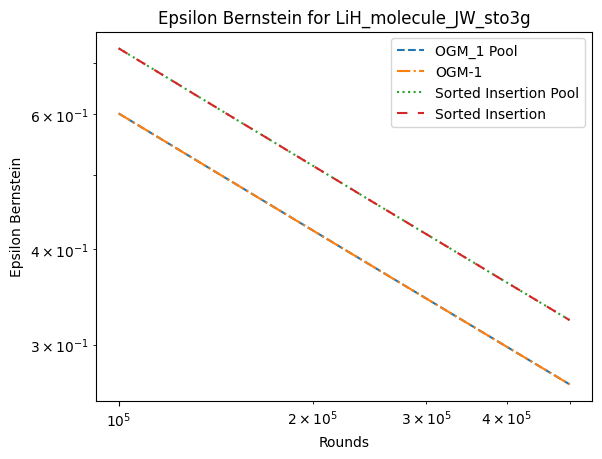

In [11]:
# import json
# import matplotlib.pyplot as plt
#bernsteinsavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\LiH_molecule_JW_sto3g_epsilon_bernstein.txt"
#savename = "LiH_molecule_JW_sto3g" # for title of the plot


#Epsilon Bernstein vs rounds plot
with open(bernsteinsavename, "r") as f:
    data = json.load(f)

plt.figure()

linestyles = [
    
    "--",             # dashed
    "-.",             # dash-dot
    ":",              # dotted
    (0, (5, 5)),      # long dashed
    (0, (3, 5, 1, 5)), # dash-dot-dot
    "-",              # solid
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
    (0, (8, 2, 2, 2))
]

for (method, values), ls in zip(data.items(), linestyles):
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method, linestyle=ls)

# for method, values in data.items():
#     n = [v["n"] for v in values]
#     eps = [v["epsilon"] for v in values]
#     plt.plot(n, eps, label=method)


plt.xlabel("Rounds")
plt.ylabel("Epsilon Bernstein")
plt.title(f"Epsilon Bernstein for {savename}")
plt.legend()
plt.yscale('log')
plt.xscale('log')
#plt.xlim(left=70000)
#plt.ylim(top=1)
plt.show()

<h3>Diagonal Proxy of Variance<h3>

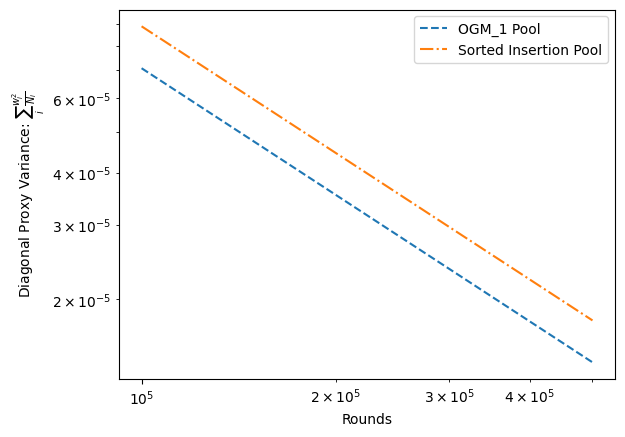

In [12]:
# import json
# import matplotlib.pyplot as plt
# bernsteinsavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\LiH_molecule_JW_sto3g_diagonal_proxy_variance.txt"
# savename = "LiH_molecule_JW_sto3g" # for title of the plot


#Epsilon Bernstein vs rounds plot
with open(DPVariancesavename, "r") as f:
    data = json.load(f)

plt.figure()

linestyles = [
    
    "--",             # dashed
    "-.",             # dash-dot
    ":",              # dotted
    (0, (5, 5)),      # long dashed
    (0, (3, 5, 1, 5)), # dash-dot-dot
    "-",              # solid
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
    (0, (8, 2, 2, 2))
]

for (method, values), ls in zip(data.items(), linestyles):
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method, linestyle=ls)

# for method, values in data.items():
#     n = [v["n"] for v in values]
#     eps = [v["epsilon"] for v in values]
#     plt.plot(n, eps, label=method)


plt.xlabel("Rounds")
plt.ylabel(r"Diagonal Proxy Variance: $\sum_i \frac{w_i^2}{N_i}$")
#plt.title(f"Epsilon Bernstein for {savename}")
plt.legend()
plt.yscale('log')
plt.xscale('log')
#plt.xlim(left=70000)
#plt.ylim(top=1)
plt.show()

<h3>Full Variance<h3>

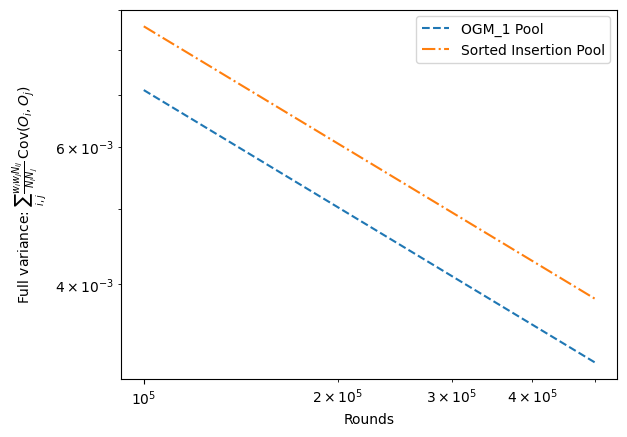

In [13]:
# import json
# import matplotlib.pyplot as plt
#bernsteinsavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\LiH_molecule_JW_sto3g_full_variance.txt"
#savename = "LiH_molecule_JW_sto3g" # for title of the plot



#Epsilon Bernstein vs rounds plot
with open(fullvariancesavename, "r") as f:
    data = json.load(f)

plt.figure()

linestyles = [
    
    "--",             # dashed
    "-.",             # dash-dot
    ":",              # dotted
    (0, (5, 5)),      # long dashed
    (0, (3, 5, 1, 5)), # dash-dot-dot
    "-",              # solid
    (0, (5, 2)),
    (0, (3, 1, 1, 1)),
    (0, (8, 2, 2, 2))
]

for (method, values), ls in zip(data.items(), linestyles):
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method, linestyle=ls)

# for method, values in data.items():
#     n = [v["n"] for v in values]
#     eps = [v["epsilon"] for v in values]
#     plt.plot(n, eps, label=method)


plt.xlabel("Rounds")
plt.ylabel(r"Full variance: $\sum_{i,j}\frac{w_i w_j N_{ij}}{N_iN_j}\,\mathrm{Cov}(O_i,O_j)$")
#plt.title(f"Epsilon Bernstein for {savename}")
plt.legend()
plt.yscale('log')
plt.xscale('log')
#plt.xlim(left=70000)
#plt.ylim(top=1)
plt.show()

<h3>chebyshev tighter<h3>

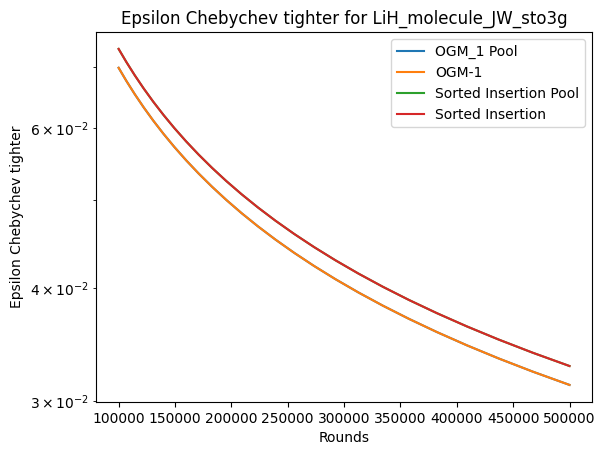

In [14]:
# import json
# import matplotlib.pyplot as plt
# chebyshevtightersavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\NH3_molecule_JW_sto3g_epsilon_chebyshev_tighter.txt"
# savename = "NH3_molecule_JW_sto3g" # for title of the plot

#Chebychev tighter vs rounds plot
with open(chebyshevtightersavename, "r") as f:
    data = json.load(f)

plt.figure()

for method, values in data.items():
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method)

plt.xlabel("Rounds")
plt.ylabel("Epsilon Chebychev tighter")
plt.title(f"Epsilon Chebychev tighter for {savename}")
plt.legend()
plt.yscale('log')
#plt.xlim(left=1000)
plt.show()

<h3>chebyshev tightest<h3>

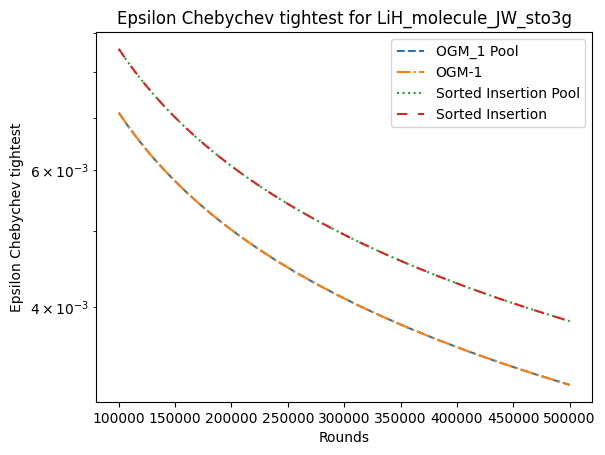

In [15]:
# import json
# import matplotlib.pyplot as plt
# chebyshevtightestsavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\NH3_molecule_JW_sto3g_epsilon_chebyshev_tightest.txt"
# savename = "NH3_molecule_JW_sto3g" # for title of the plot

#Chebychev tightest vs rounds plot
with open(chebyshevtightestsavename, "r") as f:
    data = json.load(f)

plt.figure()

# for method, values in data.items():
#     n = [v["n"] for v in values]
#     eps = [v["epsilon"] for v in values]
#     plt.plot(n, eps, label=method)

linestyles = [
    
    "--",             # dashed
    "-.",             # dash-dot
    ":",              # dotted
    (0, (5, 5)),      # long dashed
    (0, (3, 5, 1, 5)), # dash-dot-dot
    "-",              # solid
    (0, (5, 2)),
    (0, (3, 1, 1, 1))
]


for (method, values), ls in zip(data.items(), linestyles):
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method, linestyle=ls)

plt.xlabel("Rounds")
plt.ylabel("Epsilon Chebychev tightest")
plt.title(f"Epsilon Chebychev tightest for {savename}")
plt.legend()
plt.yscale('log')
#plt.xscale('log')
#plt.xlim(left=8000)
#plt.ylim(top=1e-1)
plt.show()

<h3>Empirical Results<h3>

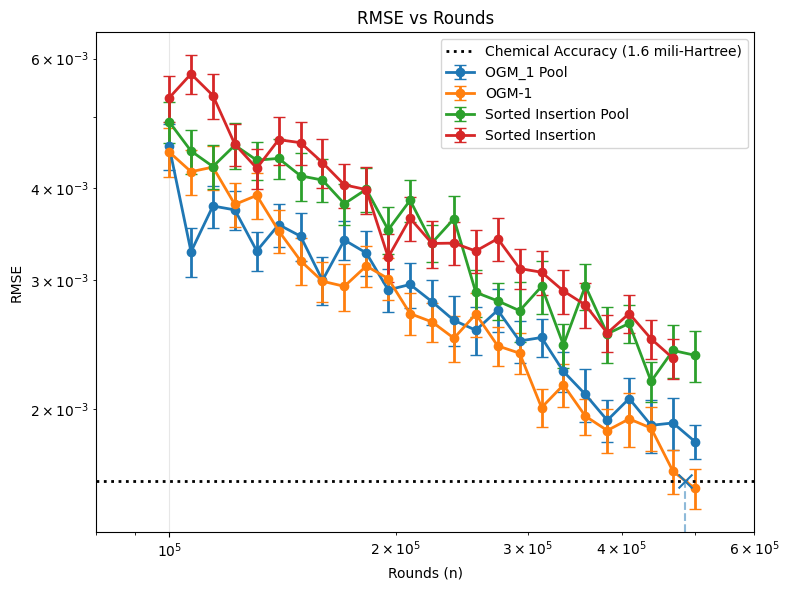

In [16]:
#import json
#import numpy as np
#import matplotlib.pyplot as plt
#rmsesavename = r"C:\Users\Abbas\Priori\generated_data\convexoptimization\NH3_molecule_JW_sto3g_rmse_13000000rounds.txt"
#savename = "NH3_molecule_JW_sto3g" # for title of the plot

with open(rmsesavename, "r") as f:
    data = json.load(f)

chemical_accuracy = 1.6e-3

fig, ax = plt.subplots(figsize=(8, 6))

crossings = {}

for method, series in data.items():

    series = sorted(series, key=lambda d: d["n"])

    x = np.array([d["n"] for d in series], dtype=float)
    y = np.array([d["rmse"] for d in series], dtype=float)
    yerr = np.array([d["std"] for d in series], dtype=float)

    # find crossing point with chemical accuracy (interpolated in log-log)
    crossing_n = None
    for i in range(len(y) - 1):
        if (y[i] > chemical_accuracy and y[i+1] <= chemical_accuracy) or \
           (y[i] < chemical_accuracy and y[i+1] >= chemical_accuracy):

            lx1, lx2 = np.log10(x[i]), np.log10(x[i+1])
            ly1, ly2 = np.log10(y[i]), np.log10(y[i+1])
            ly_target = np.log10(chemical_accuracy)

            frac = (ly_target - ly1) / (ly2 - ly1)
            lx_target = lx1 + frac * (lx2 - lx1)

            crossing_n = 10 ** lx_target
            break

    # Add crossing to legend label if found
    label_text = method if crossing_n is None else f"{method}"

    ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4, linewidth=2, label=label_text)
    # ax.errorbar(x, y,
    # yerr=yerr,
    # marker="o",
    # linestyle="none",   # <-- no connecting line
    # capsize=4,
    # label=label_text)

    if crossing_n is not None:
        crossings[method] = crossing_n
        ax.scatter(crossing_n, chemical_accuracy, marker="x", s=100, zorder=10)

ax.axhline(
    y=chemical_accuracy,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Chemical Accuracy (1.6 mili-Hartree)",
    #label="2 mili-Hartree"
    )

ax.set_xscale("log")
ax.set_yscale("log")

xmin = min(min(d["n"] for d in s) for s in data.values())
xmax = max(max(d["n"] for d in s) for s in data.values())
ax.set_xlim(xmin * 0.8, xmax * 1.2)

# vertical lines for crossings
ymin = ax.get_ylim()[0]
for xn in crossings.values():
    ax.vlines(xn, ymin, chemical_accuracy, linestyle="--", alpha=0.5)

ax.set_xlabel("Rounds (n)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Rounds")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()